# Project 00 — Tweets: Sentiment Analysis

## Setup env

In [1]:
# pip install nltk gensim scikit-learn numpy seaborn pyspellchecker scipy

In [2]:
# import nltk

# nltk.download('punkt')
# nltk.download('punkt_tab')
# nltk.download('stopwords')
# nltk.download('wordnet')
# nltk.download('averaged_perceptron_tagger')
# nltk.download('averaged_perceptron_tagger_eng')

## Data Exploration

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from spellchecker import SpellChecker
from nltk import pos_tag
from nltk.corpus import wordnet
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV
from scipy.sparse import hstack

RANDOM_STATE = 42

/home/hlakhal-/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [4]:
def load_tweet_file(path):
    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        content = f.read()
    if '\n' in content.strip() and content.count('\n') > 5:
        tweets = [line.strip() for line in content.split('\n') if line.strip()]
    else:
        tweets = [t.strip() for t in content.split(',') if t.strip()]
    return pd.DataFrame({'tweets': tweets})

neg = load_tweet_file('../data/processedNegative.csv')
pos = load_tweet_file('../data/processedPositive.csv')
neu = load_tweet_file('../data/processedNeutral.csv')

print(neg.shape, pos.shape, neu.shape)

(1116, 1) (1183, 1) (1566, 1)


(3865, 2)
label
Neutral     1566
Positive    1183
Negative    1116
Name: count, dtype: int64


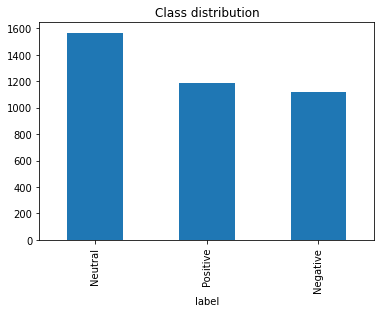

In [5]:
neg['label'] = 'Negative'
pos['label'] = 'Positive'
neu['label'] = 'Neutral'

df = pd.concat([neg, pos, neu], ignore_index=True)
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(df.shape)
print(df['label'].value_counts())

df['label'].value_counts().plot(kind='bar')
plt.title('Class distribution')
plt.show()

In [6]:
df['char_length'] = df['tweets'].apply(len)
df['word_count'] = df['tweets'].apply(lambda x: len(x.split()))

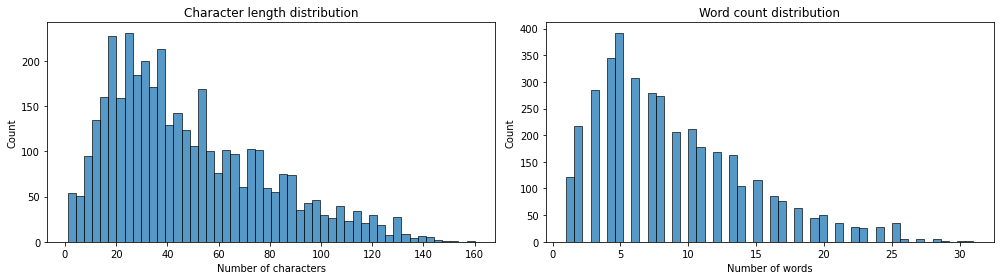

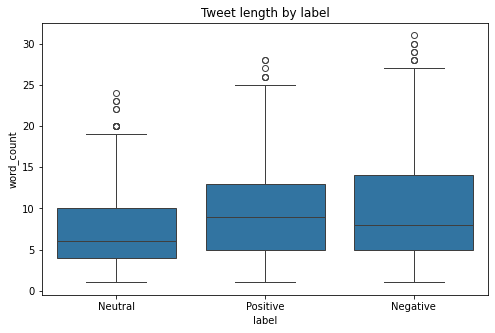

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['char_length'], bins=50, ax=axes[0])
axes[0].set_title('Character length distribution')
axes[0].set_xlabel('Number of characters')

sns.histplot(df['word_count'], bins=50, ax=axes[1])
axes[1].set_title('Word count distribution')
axes[1].set_xlabel('Number of words')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='label', y='word_count')
plt.title('Tweet length by label')
plt.show()

In [8]:
n_dup = df.duplicated(subset='tweets').sum()
print(f"Exact duplicate tweets: {n_dup}")

duplicates_check = df[df.duplicated(subset='tweets', keep=False)]
label_consistency = duplicates_check.groupby('tweets')['label'].nunique()
inconsistent = label_consistency[label_consistency > 1]
print(f"Duplicates with inconsistent labels: {len(inconsistent)}")

Exact duplicate tweets: 414
Duplicates with inconsistent labels: 1


## Text cleaning

In [9]:
def basic_clean(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r"[^a-zA-Z'\s_]", '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [10]:
contractions_dict = {
    "n't": " not",
    "'d": " would",
    "'m": " am",
    "'s": " is"
}

def expand_contractions(text):
    for key, val in contractions_dict.items():
        text = text.replace(key, val)
    return text

In [11]:

df_clean = df.dropna(subset=['tweets']).copy()

df_clean['clean_tweets'] = df_clean['tweets'].apply(basic_clean)
df_clean['clean_tweets'] = df_clean['clean_tweets'].apply(expand_contractions)

df_clean = df_clean[df_clean['clean_tweets'].str.strip() != '']
df_clean = df_clean.drop_duplicates(subset='clean_tweets', keep='first').reset_index(drop=True)

df_clean['word_count_clean'] = df_clean['clean_tweets'].apply(lambda x: len(x.split()))


print(f"Original dataset shape: {df.shape}")
print(f"Clean Data shape: {df_clean.shape}")

Original dataset shape: (3865, 4)
Clean Data shape: (3410, 6)


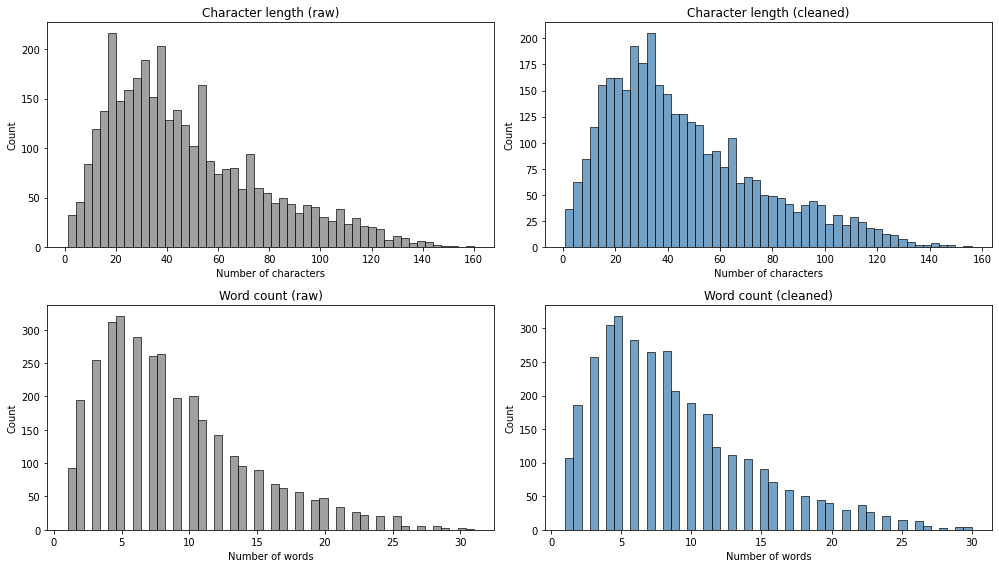

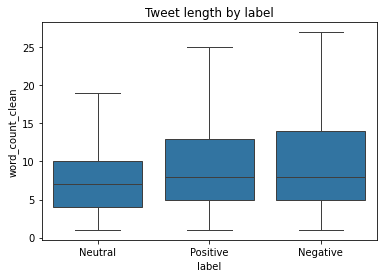

Average character length dropped by 3.0% after cleaning
Average word count dropped by -0.1% after cleaning


In [12]:
df_clean['char_length_raw'] = df_clean['tweets'].apply(len)
df_clean['char_length_clean'] = df_clean['clean_tweets'].apply(len)
df_clean['word_count_raw'] = df_clean['tweets'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(df_clean['char_length_raw'], bins=50, ax=axes[0, 0], color='gray')
axes[0, 0].set_title('Character length (raw)')
axes[0, 0].set_xlabel('Number of characters')

sns.histplot(df_clean['char_length_clean'], bins=50, ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Character length (cleaned)')
axes[0, 1].set_xlabel('Number of characters')

sns.histplot(df_clean['word_count_raw'], bins=50, ax=axes[1, 0], color='gray')
axes[1, 0].set_title('Word count (raw)')
axes[1, 0].set_xlabel('Number of words')

sns.histplot(df_clean['word_count_clean'], bins=50, ax=axes[1, 1], color='steelblue')
axes[1, 1].set_title('Word count (cleaned)')
axes[1, 1].set_xlabel('Number of words')

plt.tight_layout()
plt.show()

sns.boxplot(data=df_clean, x='label', y='word_count_clean', showfliers=False)
plt.title("Tweet length by label")
plt.show()

avg_char_drop = 1 - (df_clean['char_length_clean'].mean() / df_clean['char_length_raw'].mean())
avg_word_drop = 1 - (df_clean['word_count_clean'].mean() / df_clean['word_count_raw'].mean())
print(f"Average character length dropped by {avg_char_drop:.1%} after cleaning")
print(f"Average word count dropped by {avg_word_drop:.1%} after cleaning")

## Preprocessing variants

In [13]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

In [14]:
def tokenize_only(text):
    tokens = word_tokenize(text)
    return ' '.join(tokens)

df_clean['tokenized'] = df_clean['clean_tweets'].apply(tokenize_only)

In [15]:
def apply_stemming(text):
    tokens = word_tokenize(text)
    stemmed = [stemmer.stem(t) for t in tokens]
    return ' '.join(stemmed)

df_clean['stemmed'] = df_clean['clean_tweets'].apply(apply_stemming)

In [16]:
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def apply_lemmatization(text):
    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)
    lemmatized = [lemmatizer.lemmatize(t, get_wordnet_pos(tag)) for t, tag in tagged]
    return ' '.join(lemmatized)

df_clean['lemmatized'] = df_clean['clean_tweets'].apply(apply_lemmatization)

In [17]:
spell = SpellChecker()

def correct_spelling(text):
    tokens = text.split()
    corrected = []
    for t in tokens:
        c = spell.correction(t)
        corrected.append(c if c is not None else t)
    return ' '.join(corrected)

df_clean['spell_corrected'] = df_clean['clean_tweets'].apply(correct_spelling)

In [18]:
df_clean['stemmed_misspellings'] = df_clean['spell_corrected'].apply(apply_stemming)
df_clean['lemmatized_misspellings'] = df_clean['spell_corrected'].apply(apply_lemmatization)

In [19]:
negation_words = {'no', 'not', 'nor'}
stop_words_keep_negation = stop_words - negation_words

def remove_stopwords_keep_negation(text):
    tokens = text.split()
    return ' '.join(t for t in tokens if t not in stop_words_keep_negation)

df_clean['lemmatized_no_stopwords'] = df_clean['lemmatized'].apply(remove_stopwords_keep_negation)
df_clean['bigram_ready'] = df_clean['lemmatized']

In [20]:
preprocessing_variants = {
    'tokenization': df_clean['tokenized'],
    'stemming': df_clean['stemmed'],
    'lemmatization': df_clean['lemmatized'],
    'stemming_misspellings': df_clean['stemmed_misspellings'],
    'lemmatization_misspellings': df_clean['lemmatized_misspellings'],
    'lemmatization_no_stopwords': df_clean['lemmatized_no_stopwords'],
    'ngrams_bigram': df_clean['bigram_ready'],
}

df_clean['label'].value_counts()

label
Neutral     1465
Negative     973
Positive     972
Name: count, dtype: int64

## Vectorization (binary / count / TF-IDF, all preprocessing variants)

In [21]:
vectorization_types = ['binary', 'count', 'tfidf']
matrix_table = pd.DataFrame(index=preprocessing_variants.keys(), columns=vectorization_types)
vectorizer_table = pd.DataFrame(index=preprocessing_variants.keys(), columns=vectorization_types)

for name, series in preprocessing_variants.items():
    ngram_range = (1, 2) if name == 'ngrams_bigram' else (1, 1)

    binary_vec = CountVectorizer(binary=True, ngram_range=ngram_range)
    X_binary = binary_vec.fit_transform(series)

    count_vec = CountVectorizer(binary=False, ngram_range=ngram_range)
    X_count = count_vec.fit_transform(series)

    tfidf_vec = TfidfVectorizer(ngram_range=ngram_range)
    X_tfidf = tfidf_vec.fit_transform(series)

    matrix_table.loc[name, 'binary'] = X_binary
    matrix_table.loc[name, 'count'] = X_count
    matrix_table.loc[name, 'tfidf'] = X_tfidf

    vectorizer_table.loc[name, 'binary'] = binary_vec
    vectorizer_table.loc[name, 'count'] = count_vec
    vectorizer_table.loc[name, 'tfidf'] = tfidf_vec

print("Vocabulary sizes (tfidf):")
for name in preprocessing_variants:
    print(f"  {name}: {matrix_table.loc[name, 'tfidf'].shape[1]}")

Vocabulary sizes (tfidf):
  tokenization: 6281
  stemming: 5071
  lemmatization: 5355
  stemming_misspellings: 4457
  lemmatization_misspellings: 4730
  lemmatization_no_stopwords: 5257
  ngrams_bigram: 23149


## Similarity — top-10 most similar tweet pairs, per preprocessing variant

In [22]:
def get_top_similar_pairs(similarity_matrix, texts, top_n=10):
    texts_arr = texts.values
    n = len(texts_arr)

    iu, ju = np.triu_indices(n, k=1)
    sims = similarity_matrix[iu, ju]

    same_text = texts_arr[iu] == texts_arr[ju]
    sims_masked = np.where(same_text, -1, sims)

    top_idx = np.argsort(sims_masked)[::-1][:top_n]

    results = []
    for k in top_idx:
        i, j = iu[k], ju[k]
        results.append({
            'tweet_1': texts_arr[i],
            'tweet_2': texts_arr[j],
            'similarity': sims_masked[k]
        })
    return pd.DataFrame(results)

all_top_pairs = {}

for name, texts_series in preprocessing_variants.items():
    for vec_type in vectorization_types:
        X = matrix_table.loc[name, vec_type]
        sim_matrix = cosine_similarity(X)
        top10_df = get_top_similar_pairs(sim_matrix, texts_series, top_n=10)
        all_top_pairs[f"{name}__{vec_type}"] = top10_df

        print(f"--- Top 10 Similar Pairs for: {name} / {vec_type} ---")
        display(top10_df)

--- Top 10 Similar Pairs for: tokenization / binary ---


,tweet_1,tweet_2,similarity
0,i miss you unhappy,miss you unhappy,1.000000
1,well,' well,1.000000
2,thanks,thanks d,1.000000
3,thanks b happy,thanks happy,1.000000
4,hi we tried to call your number but got no res...,hi we tried to call your number but got no res...,0.978019
5,hi we tried to call your number but got no res...,hi ashish we tried to call your number but got...,0.977008
6,hi we tried to call your number but got no res...,hi we tried to call your number but got no res...,0.977008
7,hey thanks for being top new followers this we...,hey thanks for being my top new followers this...,0.963624
8,share the love thanks for being top new follow...,share the love thanks for being top new follow...,0.963624
9,share the love thanks for being top new follow...,share the love thanks for being top new follow...,0.960769


--- Top 10 Similar Pairs for: tokenization / count ---


,tweet_1,tweet_2,similarity
0,i miss you unhappy,miss you unhappy,1.000000
1,thanks,thanks d,1.000000
2,well,' well,1.000000
3,thanks b happy,thanks happy,1.000000
4,hi we tried to call your number but got no res...,hi we tried to call your number but got no res...,0.979796
5,hey thanks for being top new followers this we...,hey thanks for being my top new followers this...,0.970143
6,are dying of thirst and it is all because of u...,koalas are dying of thirst and it is all becau...,0.966092
7,hi we tried to call your number but got no res...,hi we tried to call your number but got no res...,0.965616
8,hi we tried to call your number but got no res...,hi ashish we tried to call your number but got...,0.957427
9,thanks for the recent follow much appreciated ...,for the recent follow much appreciated happy w...,0.948683


--- Top 10 Similar Pairs for: tokenization / tfidf ---


...

,tweet_1,tweet_2,similarity
0,thanks b happy,thanks happy,1.000000
1,well,' well,1.000000
2,thanks,thanks d,1.000000
3,i miss you unhappy,miss you unhappy,1.000000
4,hi we try to call your number but get no respo...,hi we try to call your number but get no respo...,0.966353
5,hi we try to call your number but get no respo...,hi we try to call your number but get no respo...,0.953746
6,be die of thirst and it be all because of u un...,koala be die of thirst and it be all because o...,0.951190
7,thanks for the recent follow much appreciate h...,for the recent follow much appreciate happy wa...,0.945905
8,share the love thanks for be top new follower ...,share the love thanks for be top new follower ...,0.943564
9,hi we try to call your number but get no respo...,hi we try to call your number but get no respo...,0.943090


--- Top 10 Similar Pairs for: ngrams_bigram / count ---


,tweet_1,tweet_2,similarity
0,thanks b happy,thanks happy,1.000000
1,well,' well,1.000000
2,thanks,thanks d,1.000000
3,i miss you unhappy,miss you unhappy,1.000000
4,be die of thirst and it be all because of u un...,koala be die of thirst and it be all because o...,0.962250
5,hi we try to call your number but get no respo...,hi we try to call your number but get no respo...,0.959984
6,hi we try to call your number but get no respo...,hi we try to call your number but get no respo...,0.956748
7,thanks for the recent follow much appreciate h...,for the recent follow much appreciate happy wa...,0.945905
8,hi we try to call your number but get no respo...,hi we try to call your number but get no respo...,0.939336
9,hey thanks for be top new follower this week m...,hey thanks for be my top new follower this wee...,0.933852


--- Top 10 Similar Pairs for: ngrams_bigram / tfidf ---


,tweet_1,tweet_2,similarity
0,well,' well,1.000000
1,i miss you unhappy,miss you unhappy,1.000000
2,thanks,thanks d,1.000000
3,thanks b happy,thanks happy,1.000000
4,thanks for the recent follow much appreciate h...,for the recent follow much appreciate happy wa...,0.952609
5,hi we try to call your number but get no respo...,hi we try to call your number but get no respo...,0.949724
6,hi we try to call your number but get no respo...,hi we try to call your number but get no respo...,0.944390
7,hey thanks for be top new follower this week m...,hey thanks for be top new follower this week m...,0.936160
8,share the love thanks for be top new follower ...,share the love thanks for be top new follower ...,0.934011
9,hi we try to call your number but get no respo...,hi we try to call your number but get no respo...,0.930607


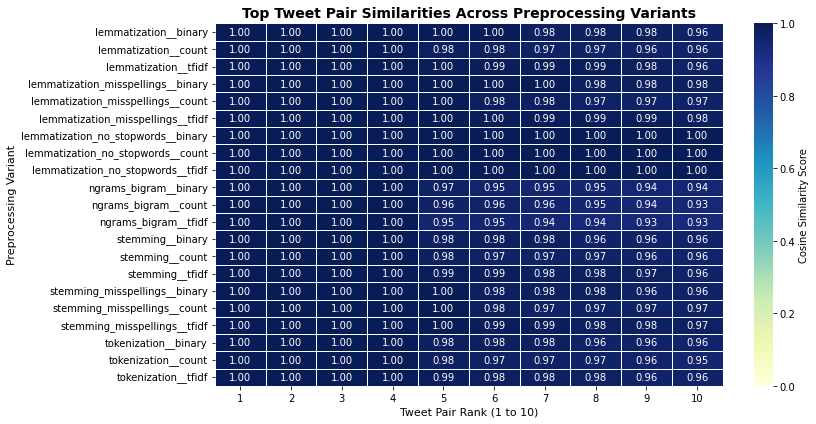

In [23]:
heatmap_data = []
for name, top10_df in all_top_pairs.items():
    temp_df = top10_df.copy()
    temp_df['variant'] = name
    temp_df['pair_rank'] = range(1, len(temp_df) + 1)
    heatmap_data.append(temp_df[['variant', 'pair_rank', 'similarity']])

combined_df = pd.concat(heatmap_data)
pivot_df = combined_df.pivot(index='variant', columns='pair_rank', values='similarity')

plt.figure(figsize=(12, 6))
sns.heatmap(
    pivot_df,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={'label': 'Cosine Similarity Score'},
    linewidths=.5,
    vmin=0, vmax=1.0
)
plt.title('Top Tweet Pair Similarities Across Preprocessing Variants', fontsize=14, fontweight='bold')
plt.xlabel('Tweet Pair Rank (1 to 10)', fontsize=11)
plt.ylabel('Preprocessing Variant', fontsize=11)
plt.tight_layout()
plt.show()

## Machine learning — classic vectorizers, multiple preprocessing datasets

In [35]:
PARAM_GRIDS = {
    'RandomForest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 20, 40],
    },
    'LogisticRegression': {
        'C': [0.1, 0.5, 1, 2, 5],
    },
    'LinearSVC': {
        'C': [0.1, 0.5, 1, 2, 5],
    },
}

def evaluate_models(X, y, dataset_name, classifiers=None, report=False, use_gridsearch=True):
    if classifiers is None:
        classifiers = {
            'RandomForest': RandomForestClassifier(random_state=RANDOM_STATE),
            'LogisticRegression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
            'LinearSVC': LinearSVC(random_state=RANDOM_STATE, max_iter=5000),
        }

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    classes = sorted(y.unique())
    y_test_bin = label_binarize(y_test, classes=classes)

    results = {}
    best_params = {}

    for clf_name, clf in classifiers.items():
        if use_gridsearch and clf_name in PARAM_GRIDS:
            search = GridSearchCV(
                clf, PARAM_GRIDS[clf_name],
                cv=3, scoring='accuracy', n_jobs=-1
            )
            search.fit(X_train, y_train)
            best_clf = search.best_estimator_
            best_params[clf_name] = search.best_params_

        y_pred = best_clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        if hasattr(best_clf, 'predict_proba'):
            y_score = best_clf.predict_proba(X_test)
        else:
            y_score = best_clf.decision_function(X_test)

        auc = roc_auc_score(y_test_bin, y_score, multi_class='ovr')

        results[clf_name] = {'accuracy': acc, 'auc': auc}

        print(f"[{dataset_name}] {clf_name}: accuracy={acc:.4f} | auc={auc:.4f} | best_params={best_params[clf_name]}")
        if report:
            print(classification_report(y_test, y_pred))

    print()
    return results
    

In [36]:
ml_results = {}

candidate_variants = ['stemming', 'lemmatization', 'lemmatization_no_stopwords', 'ngrams_bigram']

for name in candidate_variants:
    X = matrix_table.loc[name, 'tfidf']
    ml_results[f"{name}_tfidf"] = evaluate_models(X, df_clean['label'], f"{name} | tfidf")

[stemming | tfidf] RandomForest: accuracy=0.8739 | auc=0.9619 | best_params={'max_depth': 40, 'n_estimators': 300}
[stemming | tfidf] LogisticRegression: accuracy=0.8798 | auc=0.9682 | best_params={'C': 5}
[stemming | tfidf] LinearSVC: accuracy=0.8739 | auc=0.9626 | best_params={'C': 1}

[lemmatization | tfidf] RandomForest: accuracy=0.8607 | auc=0.9601 | best_params={'max_depth': 40, 'n_estimators': 100}
[lemmatization | tfidf] LogisticRegression: accuracy=0.8768 | auc=0.9662 | best_params={'C': 5}
[lemmatization | tfidf] LinearSVC: accuracy=0.8754 | auc=0.9603 | best_params={'C': 1}

[lemmatization_no_stopwords | tfidf] RandomForest: accuracy=0.8651 | auc=0.9511 | best_params={'max_depth': None, 'n_estimators': 300}
[lemmatization_no_stopwords | tfidf] LogisticRegression: accuracy=0.8548 | auc=0.9576 | best_params={'C': 5}
[lemmatization_no_stopwords | tfidf] LinearSVC: accuracy=0.8578 | auc=0.9497 | best_params={'C': 1}

[ngrams_bigram | tfidf] RandomForest: accuracy=0.8402 | auc=0.

In [37]:

flat_results = {}
for dataset, clf_results in ml_results.items():
    for clf_name, metrics in clf_results.items():
        flat_results[f"{dataset}__{clf_name}"] = metrics

results_df = pd.DataFrame(flat_results).T
results_df = results_df.sort_values('accuracy', ascending=False)
display(results_df)

,accuracy,auc
stemming_tfidf__LogisticRegression,0.879765,0.968169
lemmatization_tfidf__LogisticRegression,0.876833,0.966207
lemmatization_tfidf__LinearSVC,0.875367,0.960341
stemming_tfidf__RandomForest,0.873900,0.961865
stemming_tfidf__LinearSVC,0.873900,0.962650
ngrams_bigram_tfidf__LogisticRegression,0.865103,0.969473
lemmatization_no_stopwords_tfidf__RandomForest,0.865103,0.951134
ngrams_bigram_tfidf__LinearSVC,0.865103,0.965393
lemmatization_tfidf__RandomForest,0.860704,0.960063
lemmatization_no_stopwords_tfidf__LinearSVC,0.857771,0.949653


## Bonus — Word2Vec / GloVe embeddings

In [ ]:
from gensim import corpora
from gensim.utils import simple_preprocess

texts = df_clean['lemmatized_no_stopwords']
tokenized = [simple_preprocess(doc) for doc in texts]

dictionary = corpora.Dictionary(tokenized)
corpus = [dictionary.doc2bow(text) for text in tokenized]

In [ ]:
import gensim.downloader as api

glove_model = api.load("glove-twitter-100")

In [ ]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences=tokenized,
    vector_size=300,
    window=5,
    min_count=2,
    sg=1,
    workers=4,
    epochs=20,
    seed=RANDOM_STATE,
)
w2v_model.save("word2vec.model")

In [ ]:
def document_vector(tokens, wv):
    valid_words = [w for w in tokens if w in wv.key_to_index]
    if len(valid_words) == 0:
        return np.zeros(wv.vector_size)
    return np.mean(wv[valid_words], axis=0)

X_w2v_custom = np.array([document_vector(t, w2v_model.wv) for t in tokenized])
X_w2v_glove = np.array([document_vector(t, glove_model) for t in tokenized])

print("Custom Word2Vec:")
w2v_custom_results = evaluate_models(X_w2v_custom, df_clean['label'], "word2vec_custom")

print("Pretrained GloVe-Twitter:")
w2v_glove_results = evaluate_models(X_w2v_glove, df_clean['label'], "glove_twitter")

In [ ]:
best_tfidf_matrix = matrix_table.loc['lemmatization_no_stopwords', 'tfidf']
from scipy.sparse import csr_matrix

X_combined = hstack([best_tfidf_matrix, csr_matrix(X_w2v_glove)]).tocsr()

print("Combined TF-IDF + GloVe:")
combined_results = evaluate_models(X_combined, df_clean['label'], "tfidf_plus_glove", report=True)

In [ ]:
summary = {
    **{f"{k} (tfidf)": v for k, v in ml_results.items()},
    "word2vec_custom": w2v_custom_results,
    "glove_twitter": w2v_glove_results,
    "tfidf_plus_glove": combined_results,
}

summary_df = pd.DataFrame(summary).T
summary_df['best'] = summary_df.max(axis=1)
summary_df = summary_df.sort_values('best', ascending=False)
display(summary_df)

print(f"\nBest overall: {summary_df['best'].idxmax()} -> {summary_df['best'].max():.4f}")
print("Mandatory target: 0.832 | Bonus 1: 0.851 | Bonus 2: 0.873")